# Çalışmanın Amacı
- İstanbul Büyükşehir Belediyesi Açık Veri Platformundan "İSPARK Otoparklarına Ait Bilgiler" verisetinin Python kullanılarak analiz edilmesi

# Yöntem
- Açık Veri Platformundan indirilen excel verisinin enlem ve boylam verisi kullanılarak "geojson"  dosyasına dönüştürülmesi
- Python Geopandas kütüphanesi ile İSPARK ve İstanbul ilçe sınırlarının olduğu "geojson" dosyalarının okunması
- "geojson" dosyasının içindeki sütun bilgilerine göre harita oluşturulması
- İlçe bazında Şişli ilçesi İSPARK "geojson" dosyası verilerine göre görselleştime yapılması

# Sonuç
- İSPARK park tiplerinin çoğunlukla Açık ve Yol Üstü parklar olduğu ortaya çıkmıştır
- İSPARK park kapasiteleri 0-500 arasında olduğu gözlemlenmiştir
- İSPARK park kapasitesi olarak 4000 ve üzeri 4 otopark bulunmaktadır. Bu otoparklardan bir tanesi Eyup ilçesinde bulunmaktadır. Diğer üç otoparkın nüfusun az yoğun olduğu ilçelerde bulunmaktadır. İstanbul merkez ilçelerinde park kapasitelerinin düşük olduğu görülmektedir.
- Şişli ilçesinde yol üstü parklar yoğunluktadır.

##### Geopandas ve Matplotlib kütüphanesini çağırıyoruz

In [287]:
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline

### Verisetinin okunması için "geojson" dosyalarını okuyoruz

In [288]:

ispark = gpd.read_file("ispark4.geojson",encoding="utf-8")
ispark_dosya = gpd.GeoDataFrame(ispark)
ist = gpd.read_file("ilce2.geojson",encoding="utf-8")
ist_dosya = gpd.GeoDataFrame(ist)



### İSPARK "geojson" sütun bilgileri 

In [289]:
ispark_dosya.columns

Index(['OBJECTID', 'Park_ID', 'Park_Adı', 'Lokasyon_I', 'Lokasyon_K',
       'Lokasyon_A', 'Park_Tipi_', 'Park_Tipi', 'Park_Kapas', 'Calışma_',
       'Bölge_ID', 'Bölge', 'Alt_Bölge', 'Alt_Böl_1', 'İlçe_ID', 'İlçe',
       'Adres', 'Enlem_Boyl', 'Polygon_Ve', 'Boylam', 'Enlem', 'Aylık_Abo',
       'Ücretsiz_', 'Tarifesi', 'Park_Et_De', 'geometry'],
      dtype='object')

### İSPARK verisetinin ilk 5 satırının yazdırılması

In [290]:
ispark_dosya.head()

,OBJECTID,Park_ID,Park_Adı,Lokasyon_I,Lokasyon_K,Lokasyon_A,Park_Tipi_,Park_Tipi,Park_Kapas,Calışma_,...,Adres,Enlem_Boyl,Polygon_Ve,Boylam,Enlem,Aylık_Abo,Ücretsiz_,Tarifesi,Park_Et_De,geometry
0,1,359,Atatürk Bulvarı 1,150,1,0001 Atatürk Bulvarı 1,2,YOL ÜSTÜ,18,07:30-18:30,...,KEMALPAŞA MAHALLESİ ATATÜRK BULVARI 1 / EMİNÖNÜ,POINT (28.953538299155497 41.011291499669255),"MULTIPOLYGON (((28.95351077 41.01117896, 28.95...",28.953538,41.011291,0.00,15,"0-1 Saat : 10,00;1-2 Saat : 11,00;2-4 Saat ...",0,POINT (3223093.137 5014007.326)
1,2,860,Bakırköy İstanbul Caddesi 1,384,2,0002 Bakırköy İstanbul Caddesi,2,YOL ÜSTÜ,30,08:00-19:00,...,YEŞİLKÖY MAHALLESİ İSTANBUL CADDESİ ÜZERİ BAKI...,POINT (28.8747420429072 40.97837155571149),"MULTIPOLYGON (((28.87445897 40.97835591, 28.87...",28.874742,40.978372,400.00,15,"0-1 Saat : 10,00;1-2 Saat : 12,00;2-4 Saat ...",0,POINT (3214321.578 5009152.023)
2,3,861,Bakırköy İstanbul Caddesi 2,384,2,0002 Bakırköy İstanbul Caddesi,2,YOL ÜSTÜ,30,08:00-19:00,...,YEŞİLKÖY MAHALLESİ İSTANBUL CADDESİ ÜZERİ BAKI...,POINT (28.875321425593391 40.97841938898064),"MULTIPOLYGON (((28.87546464 40.97842251, 28.87...",28.875321,40.978419,400.00,15,"0-1 Saat : 10,00;1-2 Saat : 12,00;2-4 Saat ...",0,POINT (3214386.075 5009159.076)
3,4,862,Bakırköy İstanbul Caddesi 3,384,2,0002 Bakırköy İstanbul Caddesi,2,YOL ÜSTÜ,70,08:00-19:00,...,YEŞİLKÖY MAHALLESİ İSTANBUL CADDESİ ÜZERİ BAKI...,POINT (28.87595720460348 40.978472523602171),"MULTIPOLYGON (((28.87628195 40.9784853, 28.876...",28.875957,40.978473,400.00,15,"0-1 Saat : 10,00;1-2 Saat : 12,00;2-4 Saat ...",0,POINT (3214456.849 5009166.910)
4,5,867,Bakırköy İstanbul Caddesi 8,384,2,0002 Bakırköy İstanbul Caddesi,2,YOL ÜSTÜ,40,08:00-19:00,...,YEŞİLKÖY MAHALLESİ İSTANBUL CADDESİ ÜZERİ BAKI...,POINT (28.878947832742334 40.978643838182634),"MULTIPOLYGON (((28.87909771 40.97868195, 28.87...",28.878948,40.978644,400.00,15,"0-1 Saat : 10,00;1-2 Saat : 12,00;2-4 Saat ...",0,POINT (3214789.765 5009192.171)


### Geopandas "describe" fonksiyonu ile istatistik bilgilerinin yazdırılması 

In [291]:
ispark_dosya.describe()

,OBJECTID,Park_ID,Lokasyon_I,Lokasyon_K,Park_Tipi_,Park_Kapas,Bölge_ID,Alt_Bölge,İlçe_ID,Boylam,Enlem,Park_Et_De
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,1407.341997,888.047880,580.015048,2.285910,193.253078,3.700410,550.120383,20.774282,24.185034,34.269221,0.088919
std,211.165812,843.212337,691.253582,457.400743,0.750566,548.992527,0.458392,445.625740,10.568353,10.779693,15.204232,0.455138
min,1.000000,1.000000,51.000000,1.000000,1.000000,0.000000,3.000000,5.000000,2.000000,0.000000,0.000000,0.000000
25%,183.500000,654.000000,244.000000,191.000000,2.000000,30.000000,3.000000,6.000000,10.000000,28.841689,40.955630,0.000000
50%,366.000000,1467.000000,612.000000,504.000000,2.000000,50.000000,4.000000,545.000000,20.000000,28.975762,41.012744,0.000000
75%,548.500000,2128.500000,1549.500000,1012.500000,3.000000,130.000000,4.000000,1082.000000,30.000000,29.025284,41.049491,0.000000
max,731.000000,2886.000000,2090.000000,1474.000000,5.000000,5000.000000,4.000000,1083.000000,39.000000,29.326817,41.196800,10.000000


### İSPARK park tiplerine göre harita oluşturulması

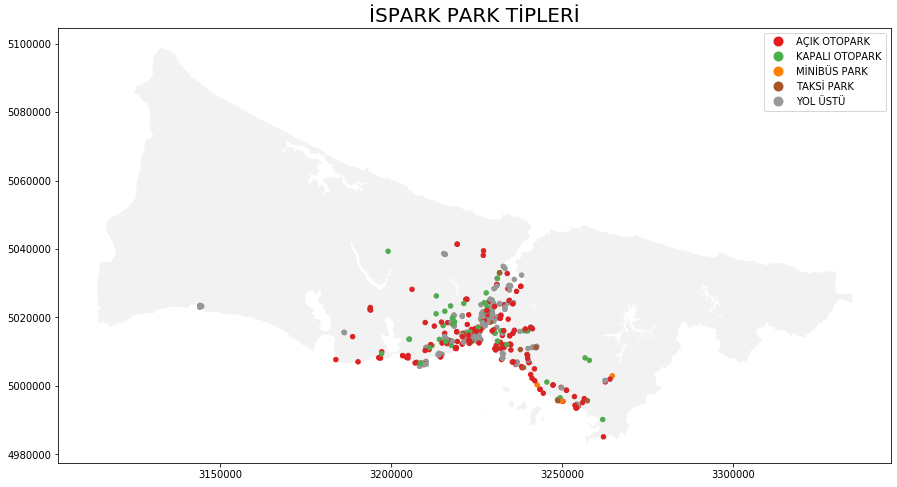

In [292]:
fig,ax = plt.subplots(1,figsize=(20, 8))


ispark_dosya.plot(ax=ax,cmap="Set1",column =ispark_dosya['Park_Tipi'],markersize=20,legend=True)
ist_dosya.plot(ax=ax,alpha =0.1,color="grey")
plt.title("İSPARK PARK TİPLERİ",fontdict ={"fontsize":20})
plt.savefig("ispark_ist_tip.jpg",dpi = 200, facecolor="w",edgecolor="w")

plt.show()

### İSPARK park kapasitesine göre harita oluşturulması 

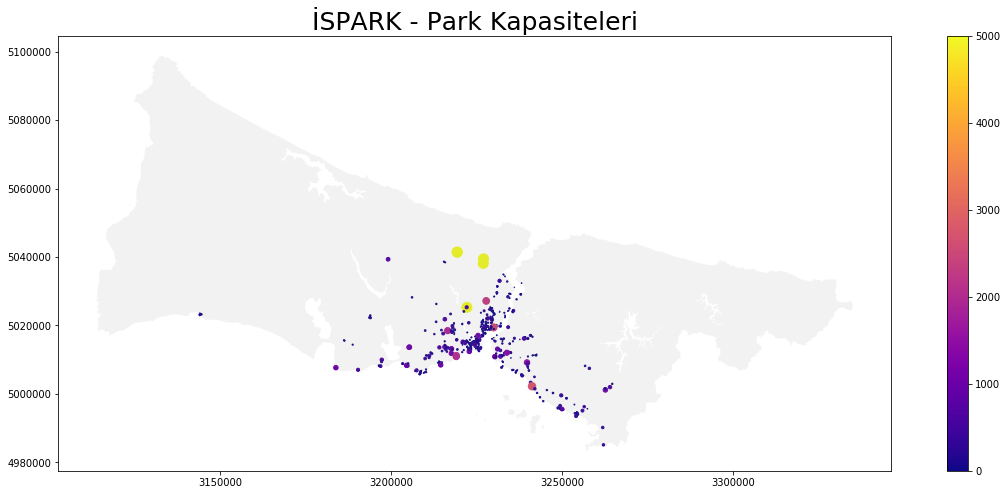

In [293]:

fig,ax = plt.subplots(1,figsize=(20,8))

ispark_dosya.plot(ax=ax,cmap="plasma",alpha=1,column =dosya["Park_Kapas"],markersize =dosya["Park_Kapas"]/50,legend=True)
ist_dosya.plot(ax=ax,alpha =0.1,color="grey")
plt.title("İSPARK - Park Kapasiteleri",fontdict={"fontsize":25})

plt.savefig("isparkpark.png",quality=50,dpi = 200, facecolor="w",edgecolor="w")
plt.show()


###  İSPARK park kapasitesi ve İstanbul ilçe nüfus bilgilerinin haritada gösterilmesi

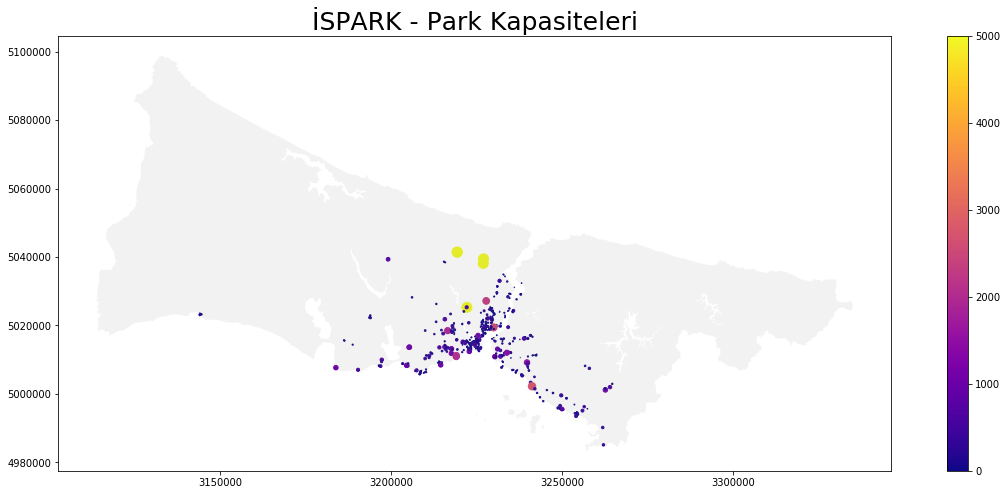

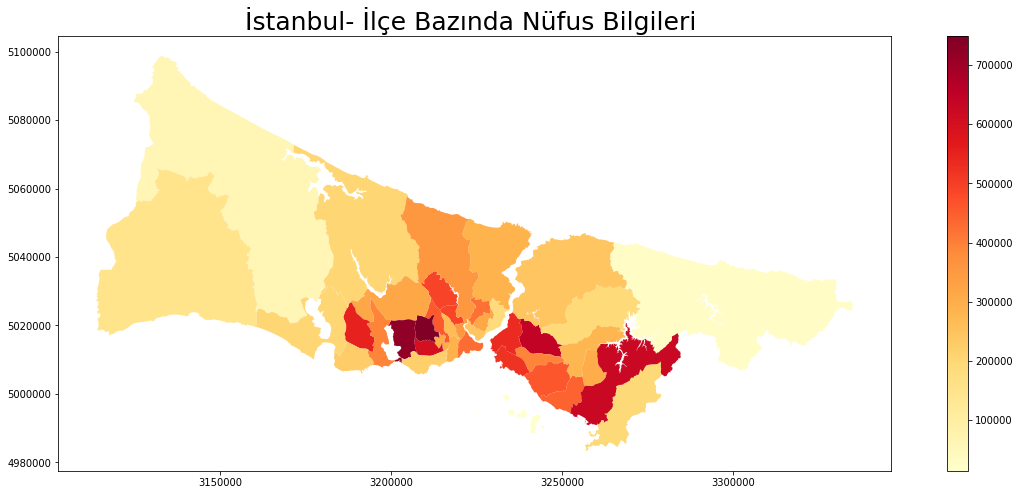

In [294]:

fig,ax = plt.subplots(figsize=(20,8))

ispark_dosya.plot(ax=ax,cmap="plasma",alpha=1,column =dosya["Park_Kapas"],markersize =dosya["Park_Kapas"]/50,legend=True)
plt.title("İSPARK - Park Kapasiteleri",fontdict={"fontsize":25})
ist_dosya.plot(ax=ax,alpha =0.1,color="grey",legend=True)
plt.savefig("ispark_ist_kapasite.png",quality=100,dpi = 200, facecolor="w",edgecolor="w")
ist_dosya.plot(figsize=(20,8),column="NUFUS",alpha =1,cmap="YlOrRd",legend=True)
plt.title("İstanbul- İlçe Bazında Nüfus Bilgileri ",fontdict={"fontsize":25})

plt.savefig("ispark_ist_nufus.png",quality=100,dpi = 200, facecolor="w",edgecolor="w")
plt.show()

In [295]:
sisli=ist_dosya[ist_dosya["ILCE_ADI"]=="ŞİŞLİ"]
sisli

,OBJECTID,ILCE_IDESK,ILCE_ID,ILCE_ADI,ILCE_UAVT,NUFUS,YAKA,Alan,SHAPE_Leng,SHAPE_Area,METIN,geometry
37,38,22,21,ŞİŞLİ,1663,318217,2,1071.302571,20638.975195,1.071303e+07,İLÇE SINIRI,"MULTIPOLYGON (((3228866.478 5026191.626, 32288..."


### İSPARK Şişli ilçesinin istatistik bilgileri
- Maksimum park kapasitesi 581, 
- Ortalama park kapasitesi 66 gibi bilgiler görülmektedir

In [296]:
sisli_ispark=gpd.GeoDataFrame(ispark_dosya[ispark_dosya["İlçe"]=="ŞİŞLİ"])
sisli_ispark.describe()


,OBJECTID,Park_ID,Lokasyon_I,Lokasyon_K,Park_Tipi_,Park_Kapas,Bölge_ID,Alt_Bölge,İlçe_ID,Boylam,Enlem,Park_Et_De
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.0,75.000000,75.0,75.000000,75.000000,75.000000
mean,307.706667,990.146667,714.626667,478.493333,2.053333,66.120000,4.0,429.226667,35.0,25.513986,36.128416,0.026667
std,247.253332,1033.481517,781.369203,499.203700,0.566958,102.929123,0.0,221.881852,0.0,9.485113,13.431146,0.162192
min,33.000000,1.000000,51.000000,19.000000,1.000000,0.000000,4.0,6.000000,35.0,0.000000,0.000000,0.000000
25%,68.500000,80.500000,73.000000,49.500000,2.000000,25.500000,4.0,544.000000,35.0,28.985781,41.046674,0.000000
50%,258.000000,194.000000,156.000000,231.000000,2.000000,40.000000,4.0,544.000000,35.0,28.991073,41.050270,0.000000
75%,522.500000,1908.500000,1483.000000,851.000000,2.000000,50.000000,4.0,544.000000,35.0,28.995041,41.059721,0.000000
max,731.000000,2885.000000,2065.000000,1442.000000,5.000000,581.000000,4.0,544.000000,35.0,29.014090,41.079949,1.000000


### İSPARK Şişli ilçesinde bulunan park tipleri
- Yol üstü parkların yoğunlukta olduğu görülmektedir

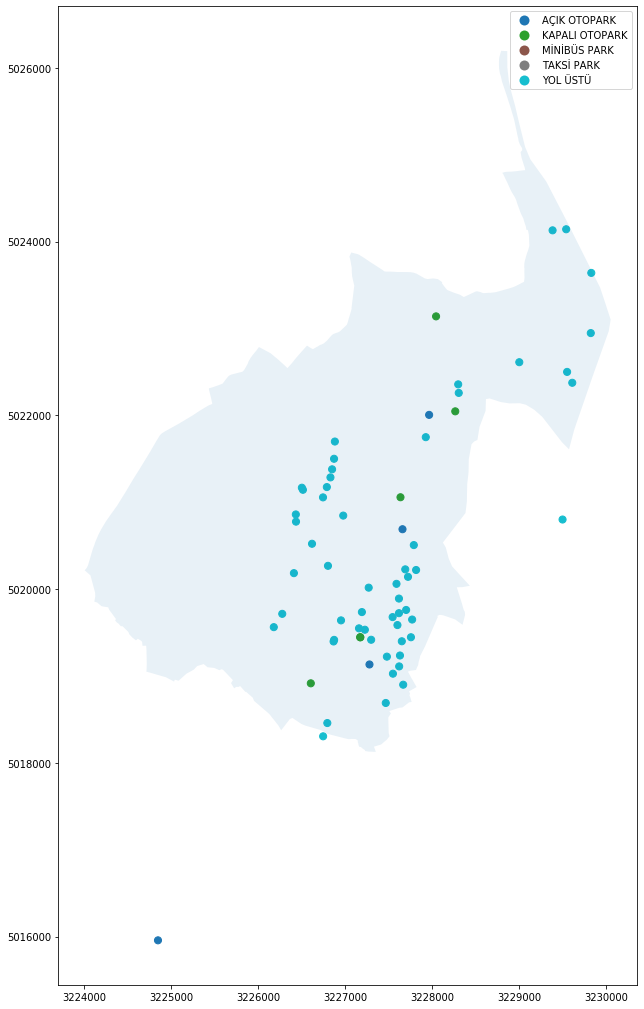

In [297]:
fig,ax = plt.subplots(figsize=(30,18))
sisli_ispark_tip = gpd.GeoDataFrame(ispark_dosya[ispark_dosya["İlçe"]=="ŞİŞLİ"])
sisli_ispark_tip.plot(ax=ax,alpha=1,column="Park_Tipi",markersize=50,legend=True)
sisli.plot(ax=ax,alpha =0.1)
plt.savefig("ispark_sisli_tip.png",quality=100,dpi = 200, facecolor="w",edgecolor="w",)
plt.show()

### İSPARK Şişli park kapasiteleri
- Park kapasitesi 0-100 arasında fazla olduğu görülmektedir

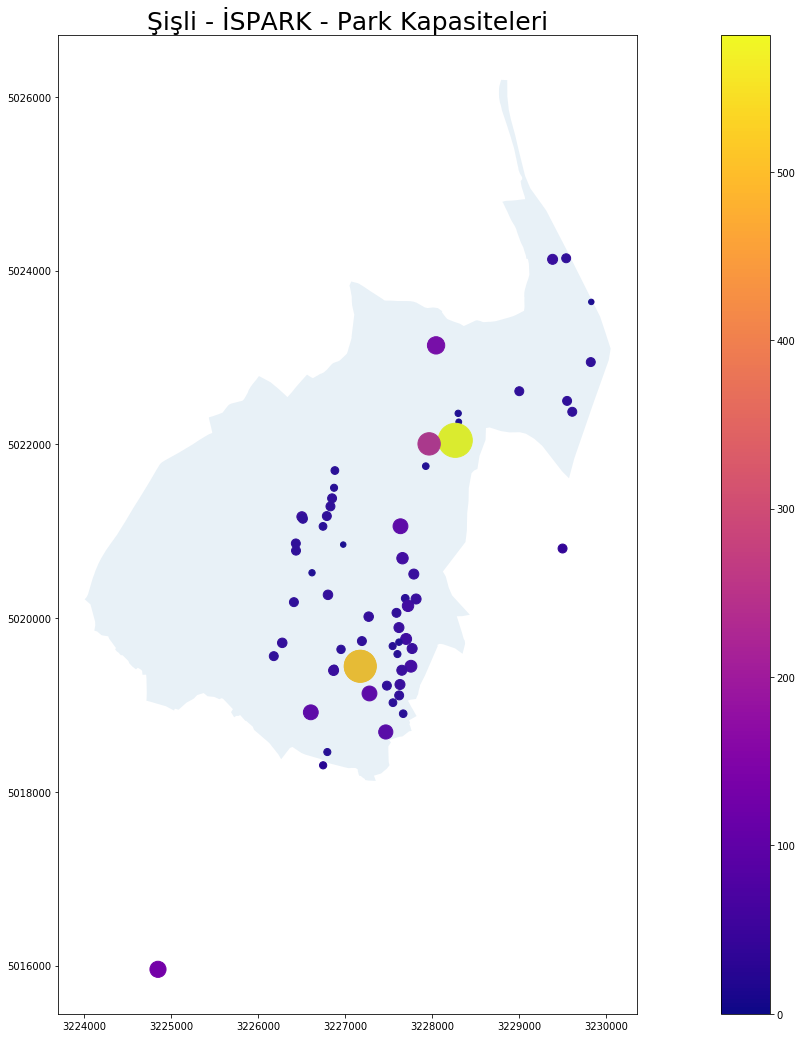

In [298]:
fig,ax = plt.subplots(figsize=(30,18))

sisli_sekil = gpd.GeoDataFrame(sisli)
plt.title("Şişli - İSPARK - Park Kapasiteleri",fontdict={"fontsize":25})
sisli_ispark.plot(ax=ax,alpha=1,column="Park_Kapas",markersize=sisli_ispark["Park_Kapas"]*2,legend=True)

sisli.plot(ax=ax,alpha =0.1)

plt.savefig("ispark_sisli_kapasite.png",quality=100,dpi = 200, facecolor="w",edgecolor="w",)

plt.show()
